## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 29469 files belonging to 8 classes.


### Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4160 files belonging to 8 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[139. 157. 133.]
   [  9.  31.   0.]
   [ 11.  37.   0.]
   ...
   [  0.   2.   0.]
   [212. 208. 209.]
   [ 13.  13.  13.]]

  [[141. 159. 133.]
   [ 14.  36.   0.]
   [ 16.  42.   3.]
   ...
   [241. 247. 245.]
   [  3.   0.   0.]
   [  0.   0.   0.]]

  [[150. 169. 141.]
   [ 22.  45.   3.]
   [ 26.  53.  10.]
   ...
   [ 48.  54.  52.]
   [ 43.  39.  40.]
   [  4.   4.   4.]]

  ...

  [[206. 216. 145.]
   [156. 174.  74.]
   [154. 178.  82.]
   ...
   [140. 181.  77.]
   [142. 183.  79.]
   [143. 184.  80.]]

  [[207. 217. 146.]
   [157. 175.  75.]
   [153. 177.  81.]
   ...
   [142. 183.  79.]
   [143. 184.  80.]
   [144. 185.  81.]]

  [[207. 217. 146.]
   [157. 175.  75.]
   [153. 177.  81.]
   ...
   [142. 183.  79.]
   [143. 184.  80.]
   [144. 185.  81.]]]


 [[[  0.   2.   0.]
   [ 10.  14.   0.]
   [  1.   0.   0.]
   ...
   [  2.   6.   0.]
   [249. 255. 248.]
   [  0.   2.   0.]]

  [[188. 203. 210.]
   [ 31.  15.  18.]
   [114. 119. 122.]
   ...
   [152. 1

### To avoid Overshooting
1. Choose small learning rate default 0.001 here we have taken 0.0001 
2. There may be chance of underfitting so increase number of neuron 
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [6]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [7]:
model = Sequential()

## Building Convolution Layer

In [8]:
model.add(Input(shape=(128, 128, 3)))

In [9]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [14]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [15]:
model.add(Flatten())

In [16]:
model.add(Dense(units=1500,activation='relu'))

In [17]:
model.add(Dropout(0.4))

In [18]:
#Output Layer
model.add(Dense(units=8,activation='softmax'))

## Compiling Model

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │          12,008 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,797,732 (29.75 MB)

 Trainable params: 7,797,732 (29.75 MB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [21]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 478s 516ms/step - accuracy: 0.6798 - loss: 0.8029 - val_accuracy: 0.8793 - val_loss: 0.3091
Epoch 2/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 426s 463ms/step - accuracy: 0.8940 - loss: 0.2929 - val_accuracy: 0.9531 - val_loss: 0.1574
Epoch 3/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 432s 469ms/step - accuracy: 0.9486 - loss: 0.1476 - val_accuracy: 0.9647 - val_loss: 0.1037
Epoch 4/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 435s 472ms/step - accuracy: 0.9671 - loss: 0.0988 - val_accuracy: 0.9760 - val_loss: 0.0716
Epoch 5/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 415s 450ms/step - accuracy: 0.9782 - loss: 0.0668 - val_accuracy: 0.9620 - val_loss: 0.1311
Epoch 6/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 413s 448ms/step - accuracy: 0.9832 - loss: 0.0534 - val_accuracy: 0.9692 - val_loss: 0.1446
Epoch 7/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 421s 457ms/step - accuracy: 0.9829 - loss: 0.0512 - val_accuracy: 0.9897 - val_loss: 0.0344
Epoch 8/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 408s 443ms/step - accuracy: 0.9878 -

## Evaluating Model

In [22]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

921/921 ━━━━━━━━━━━━━━━━━━━━ 95s 103ms/step - accuracy: 0.9950 - loss: 0.0167


In [23]:
print(train_loss, train_acc)

0.016665738075971603 0.9950456619262695


In [24]:
# Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.9865 - loss: 0.0480


In [25]:
print(val_loss, val_acc)

0.04804103821516037 0.9865384697914124


## Saving Model

In [26]:
model.save("trained_model.keras")

In [27]:
training_history.history

{'accuracy': [0.6798330545425415,
  0.8939563632011414,
  0.9486239552497864,
  0.967117965221405,
  0.9782483577728271,
  0.9831687808036804,
  0.9828633666038513,
  0.9878177046775818,
  0.9879534244537354,
  0.9877498149871826],
 'loss': [0.8029218912124634,
  0.2928798198699951,
  0.14758449792861938,
  0.09877649694681168,
  0.06675555557012558,
  0.05342577025294304,
  0.05124050751328468,
  0.036639463156461716,
  0.035949576646089554,
  0.03776612505316734],
 'val_accuracy': [0.8793269395828247,
  0.953125,
  0.9646634459495544,
  0.9759615659713745,
  0.9620192050933838,
  0.9692307710647583,
  0.9896634817123413,
  0.9901442527770996,
  0.9846153855323792,
  0.9865384697914124],
 'val_loss': [0.3090894818305969,
  0.15739969909191132,
  0.10374327003955841,
  0.07160571217536926,
  0.13112595677375793,
  0.14458714425563812,
  0.034410543739795685,
  0.03344031795859337,
  0.05044656619429588,
  0.04804104566574097]}

In [28]:
# Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [29]:
training_history.history['accuracy']

[0.6798330545425415,
 0.8939563632011414,
 0.9486239552497864,
 0.967117965221405,
 0.9782483577728271,
 0.9831687808036804,
 0.9828633666038513,
 0.9878177046775818,
 0.9879534244537354,
 0.9877498149871826]

In [30]:
training_history.history['val_accuracy']

[0.8793269395828247,
 0.953125,
 0.9646634459495544,
 0.9759615659713745,
 0.9620192050933838,
 0.9692307710647583,
 0.9896634817123413,
 0.9901442527770996,
 0.9846153855323792,
 0.9865384697914124]

### Accuracy Visualization

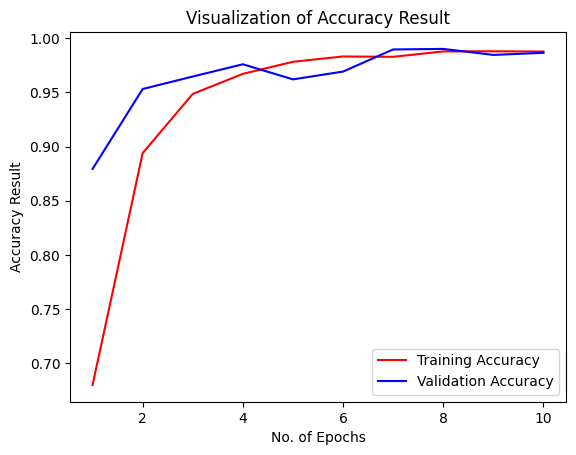

In [31]:
epochs = [i for i in range (1,11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()